# ⚽ Análise de Odds de Futebol — 1X2

**Autor:** Luccas Nunes  
**Dataset:** `odds1x2.csv` — 147.554 registros de odds coletados entre out/2025 e mar/2026  
**Ligas:** 17 ligas europeias, incluindo Premier League, La Liga, Serie A, Bundesliga, Ligue 1 e UCL

---

## Estrutura da análise

1. **ETL** — Limpeza, tipagem e engenharia de features  
2. **Análise Exploratória (EDA)** — Distribuições, volumes e comparativos por liga  
3. **Análise Aprofundada** — Margem da banca, vantagem do mandante, volatilidade e comportamento temporal das odds

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0D0D1A',
    'axes.facecolor':   '#12122A',
    'axes.edgecolor':   '#2A2A4A',
    'axes.labelcolor':  '#E2E8F0',
    'xtick.color':      '#8B9CC8',
    'ytick.color':      '#8B9CC8',
    'text.color':       '#E2E8F0',
    'grid.color':       '#1E1E3A',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'sans-serif',
    'font.size':        11,
})

PURPLE, CYAN, AMBER, ROSE, SLATE = '#8B5CF6', '#06B6D4', '#F59E0B', '#F43F5E', '#8B9CC8'
print('Bibliotecas carregadas ✓')

Bibliotecas carregadas ✓


## 1. ETL — Extração, Transformação e Carga

In [16]:
df_raw = pd.read_csv('odds1x2.csv')
print(f'Linhas brutas : {len(df_raw):,}')
print(f'Colunas       : {list(df_raw.columns)}')
df_raw.head(3)

Linhas brutas : 147,554
Colunas       : ['event_id', 'logged_time', 'sport_id', 'league_id', 'league_name', 'starts', 'home_team', 'away_team', 'home_odds', 'draw_odds', 'away_odds', 'max_money_line']


,event_id,logged_time,sport_id,league_id,league_name,starts,home_team,away_team,home_odds,draw_odds,away_odds,max_money_line
0,1616636158,2025-10-22 16:30:00,1,2627,UEFA - Champions League,2025-10-22 19:00:00,Real Madrid,Juventus,1.454,5.04,6.590,20000.0
1,1616636158,2025-10-22 19:00:00,1,2627,UEFA - Champions League,2025-10-22 19:00:00,Real Madrid,Juventus,1.438,5.07,6.870,20000.0
2,1616636161,2025-10-22 16:30:00,1,2627,UEFA - Champions League,2025-10-22 19:00:00,Eintracht Frankfurt,Liverpool,4.870,4.79,1.606,20000.0


In [17]:
df = df_raw.copy()

# Tipagem de datas
df['logged_time'] = pd.to_datetime(df['logged_time'])
df['starts']      = pd.to_datetime(df['starts'])

# Feature: horas antes do jogo
df['hours_before_start'] = (df['starts'] - df['logged_time']).dt.total_seconds() / 3600

# Limpeza: remove odds inválidas
df = df[(df['home_odds'] > 1) & (df['draw_odds'] > 1) & (df['away_odds'] > 1)]

# Probabilidade implícita
df['prob_home'] = 1 / df['home_odds']
df['prob_draw'] = 1 / df['draw_odds']
df['prob_away'] = 1 / df['away_odds']
df['overround'] = df['prob_home'] + df['prob_draw'] + df['prob_away']
df['margin_pct'] = (df['overround'] - 1) * 100

# Normalização: remove margem da banca
df['prob_home_norm'] = df['prob_home'] / df['overround']
df['prob_draw_norm'] = df['prob_draw'] / df['overround']
df['prob_away_norm'] = df['prob_away'] / df['overround']

# Favorito e azarão
df['favorite']     = np.where(df['prob_home_norm'] >= df['prob_away_norm'], 'home', 'away')
df['fav_prob']     = df[['prob_home_norm','prob_away_norm']].max(axis=1)
df['underdog_odds']= np.where(df['favorite']=='home', df['away_odds'], df['home_odds'])

# Snapshot final por evento (última cotação)
df_last = df.sort_values('logged_time').groupby('event_id').last().reset_index()

print(f'Linhas após limpeza  : {len(df):,}')
print(f'Eventos únicos       : {df["event_id"].nunique():,}')
print(f'Ligas                : {df["league_name"].nunique()}')
print(f'Período              : {df["logged_time"].min().date()} → {df["logged_time"].max().date()}')
print(f'Margem média da banca: {df["margin_pct"].mean():.2f}%')

Linhas após limpeza  : 147,554
Eventos únicos       : 2,311
Ligas                : 17
Período              : 2025-10-07 → 2026-03-12
Margem média da banca: 5.05%


In [18]:
df.describe().round(3)

,event_id,logged_time,sport_id,league_id,starts,home_odds,draw_odds,away_odds,max_money_line,hours_before_start,prob_home,prob_draw,prob_away,overround,margin_pct,prob_home_norm,prob_draw_norm,prob_away_norm,fav_prob,underdog_odds
count,1.475540e+05,147554,147554.0,147554.000,147554,147554.000,147554.000,147554.000,138154.000,147554.000,147554.000,147554.000,147554.000,147554.000,147554.000,147554.000,147554.000,147554.000,147554.000,147554.000
mean,1.620723e+09,2025-12-18 13:31:14.596418816,1.0,14859.938,2025-12-26 05:24:36.855795456,2.687,4.036,4.137,1606.296,183.890,0.458,0.261,0.331,1.050,5.049,0.436,0.249,0.316,0.520,4.900
min,1.616636e+09,2025-10-07 12:00:00,1.0,1842.000,2025-10-17 18:30:00,1.021,2.310,1.038,50.000,-6.000,0.044,0.048,0.020,1.021,2.127,0.042,0.045,0.019,0.321,2.370
25%,1.619140e+09,2025-11-15 13:30:00,1.0,1980.000,2025-11-23 19:45:00,1.709,3.390,2.270,500.000,70.000,0.319,0.236,0.207,1.039,3.881,0.305,0.224,0.197,0.423,3.230
50%,1.620912e+09,2025-12-14 03:00:00,1.0,2196.000,2025-12-20 15:00:00,2.240,3.700,3.320,500.000,150.500,0.446,0.270,0.301,1.051,5.088,0.425,0.257,0.287,0.498,4.020
75%,1.622240e+09,2026-01-21 03:00:00,1.0,2627.000,2026-01-25 17:00:00,3.130,4.240,4.840,2000.000,260.500,0.585,0.295,0.441,1.056,5.610,0.556,0.281,0.419,0.596,5.460
max,1.625890e+09,2026-03-12 10:30:00,1.0,214101.000,2026-03-18 20:00:00,22.760,20.740,51.000,40000.000,1001.000,0.979,0.433,0.963,1.151,15.075,0.926,0.394,0.880,0.926,51.000
std,2.167568e+06,NaN,0.0,48257.035,NaN,1.518,1.155,2.933,2670.301,154.377,0.183,0.050,0.166,0.013,1.340,0.174,0.048,0.158,0.120,2.712


## 2. Análise Exploratória (EDA)

### 2.1 Volume de eventos por liga

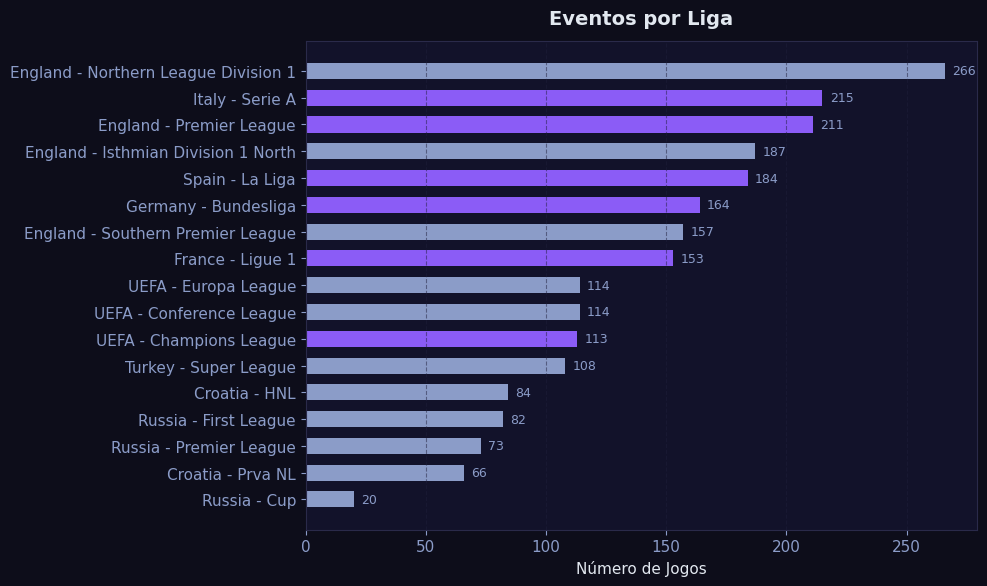

In [19]:
LEAGUES_MAIN = ['Spain - La Liga','England - Premier League','Italy - Serie A',
                'Germany - Bundesliga','France - Ligue 1','UEFA - Champions League']

events_per_league = df_last.groupby('league_name')['event_id'].count().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [PURPLE if l in LEAGUES_MAIN else SLATE for l in events_per_league.index]
bars = ax.barh(events_per_league.index, events_per_league.values, color=colors, height=0.6)
ax.set_title('Eventos por Liga', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Número de Jogos')
ax.grid(axis='x')
for bar in bars:
    ax.text(bar.get_width()+3, bar.get_y()+bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=9, color=SLATE)
plt.tight_layout(); plt.show()

### 2.2 Distribuição das odds

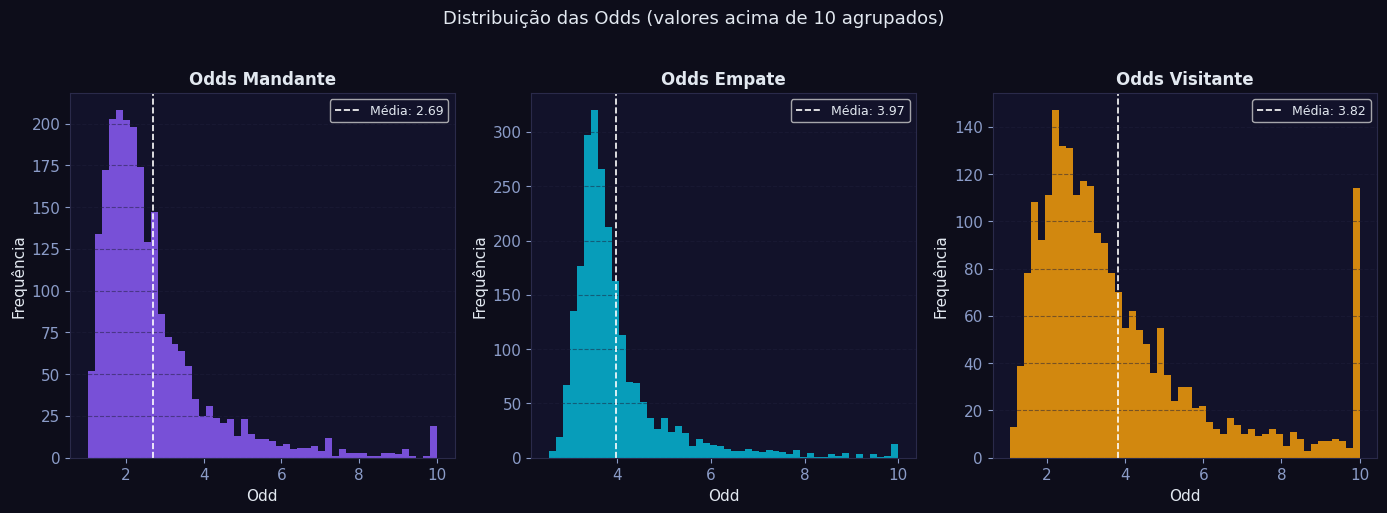

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
configs = [('home_odds','Odds Mandante',PURPLE),('draw_odds','Odds Empate',CYAN),('away_odds','Odds Visitante',AMBER)]
for ax, (col, title, color) in zip(axes, configs):
    data = df_last[col].clip(upper=10)
    ax.hist(data, bins=50, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(data.mean(), color='white', linestyle='--', linewidth=1.2, label=f'Média: {data.mean():.2f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Odd'); ax.set_ylabel('Frequência'); ax.legend(fontsize=9); ax.grid(axis='y')
fig.suptitle('Distribuição das Odds (valores acima de 10 agrupados)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

### 2.3 Margem da banca por liga

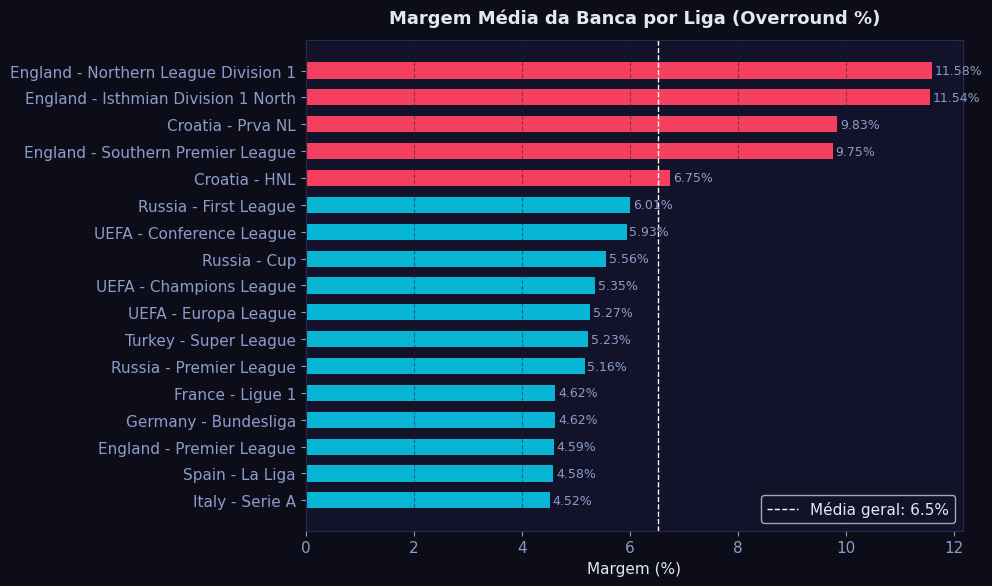


Insight: A Serie A tem a menor margem (4.52%), enquanto ligas menores chegam a 11.58%.


In [21]:
margin_by_league = df.groupby('league_name')['margin_pct'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_m = [CYAN if v < margin_by_league.mean() else ROSE for v in margin_by_league.values]
bars = ax.barh(margin_by_league.index, margin_by_league.values, color=colors_m, height=0.6)
ax.axvline(margin_by_league.mean(), color='white', linestyle='--', linewidth=1,
           label=f'Média geral: {margin_by_league.mean():.1f}%')
ax.set_title('Margem Média da Banca por Liga (Overround %)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Margem (%)'); ax.legend(); ax.grid(axis='x')
for bar in bars:
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.2f}%', va='center', fontsize=9, color=SLATE)
plt.tight_layout(); plt.show()

print(f'\nInsight: A Serie A tem a menor margem ({margin_by_league.min():.2f}%),'
      f' enquanto ligas menores chegam a {margin_by_league.max():.2f}%.')

## 3. Análise Aprofundada

### 3.1 Movimento das odds ao longo do tempo

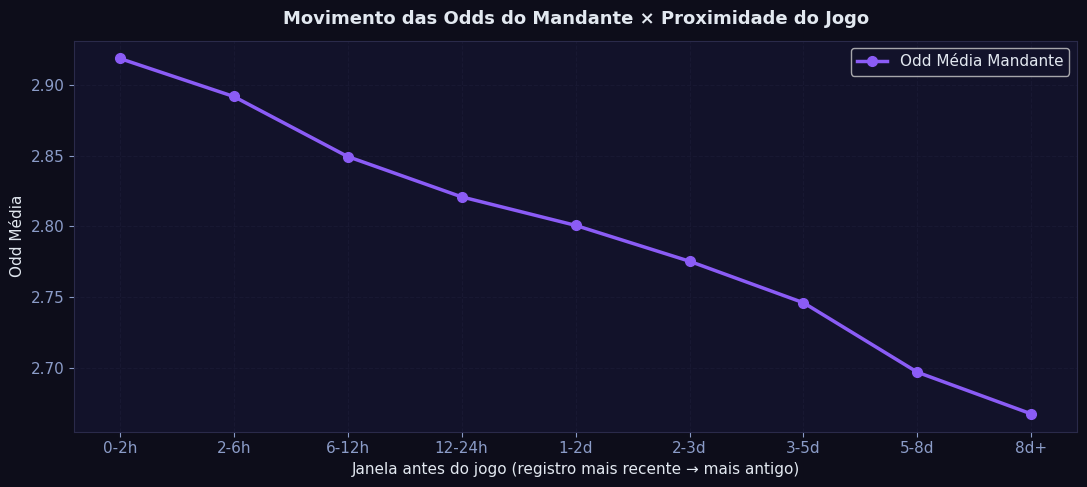

Insight: Odds do mandante caem nas últimas 24h — pressão de apostas em favor do time da casa.


In [22]:
top_leagues = df['league_name'].value_counts().head(6).index
df_top = df[df['league_name'].isin(top_leagues)].copy()

bins   = [0,2,6,12,24,48,72,120,200,500]
labels = ['0-2h','2-6h','6-12h','12-24h','1-2d','2-3d','3-5d','5-8d','8d+']
df_top['time_bin'] = pd.cut(df_top['hours_before_start'], bins=bins, labels=labels)

home_movement = df_top.groupby('time_bin', observed=True)['home_odds'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(home_movement['time_bin'].astype(str), home_movement['home_odds'],
        marker='o', color=PURPLE, linewidth=2.5, markersize=7, label='Odd Média Mandante')
ax.set_title('Movimento das Odds do Mandante × Proximidade do Jogo', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Janela antes do jogo (registro mais recente → mais antigo)')
ax.set_ylabel('Odd Média'); ax.grid(True); ax.legend()
plt.tight_layout(); plt.show()

print('Insight: Odds do mandante caem nas últimas 24h — pressão de apostas em favor do time da casa.')

### 3.2 Vantagem do mandante por liga

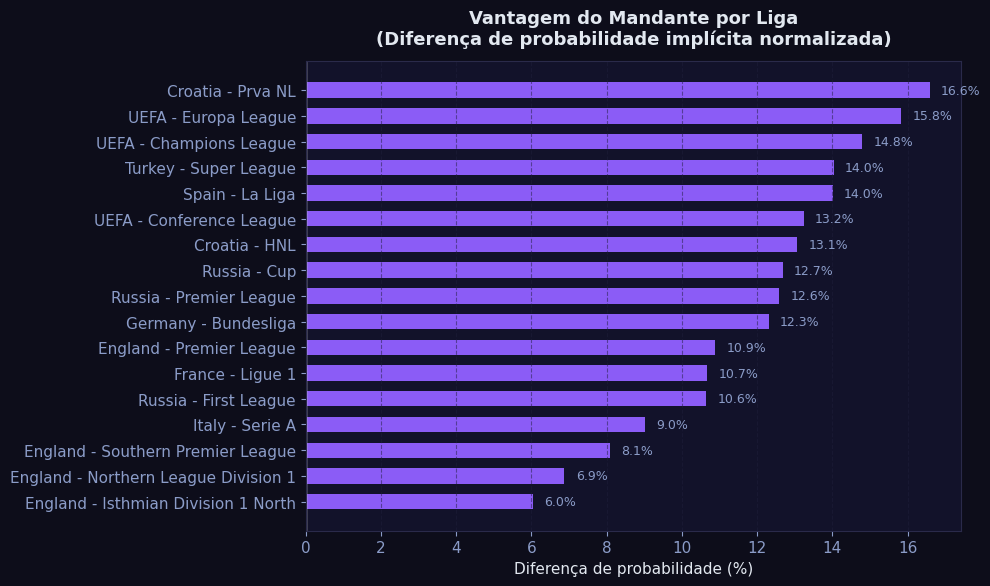

Insight: Croatia - Prva NL tem a maior vantagem do mandante (16.6pp).


In [23]:
home_adv = (
    df_last.groupby('league_name')[['prob_home_norm','prob_away_norm']]
    .mean()
    .assign(home_adv=lambda x: x['prob_home_norm'] - x['prob_away_norm'])
    .sort_values('home_adv', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors_ha = [PURPLE if v > 0 else ROSE for v in home_adv['home_adv']]
bars = ax.barh(home_adv.index, home_adv['home_adv']*100, color=colors_ha, height=0.6)
ax.axvline(0, color='white', linewidth=1)
ax.set_title('Vantagem do Mandante por Liga\n(Diferença de probabilidade implícita normalizada)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Diferença de probabilidade (%)'); ax.grid(axis='x')
for bar in bars:
    w = bar.get_width()
    ax.text(w+(0.3 if w>=0 else -0.3), bar.get_y()+bar.get_height()/2,
            f'{w:.1f}%', va='center', ha='left' if w>=0 else 'right', fontsize=9, color=SLATE)
plt.tight_layout(); plt.show()

top_ha = home_adv['home_adv'].idxmax()
print(f'Insight: {top_ha} tem a maior vantagem do mandante ({home_adv["home_adv"].max()*100:.1f}pp).')

### 3.3 Correlação entre variáveis

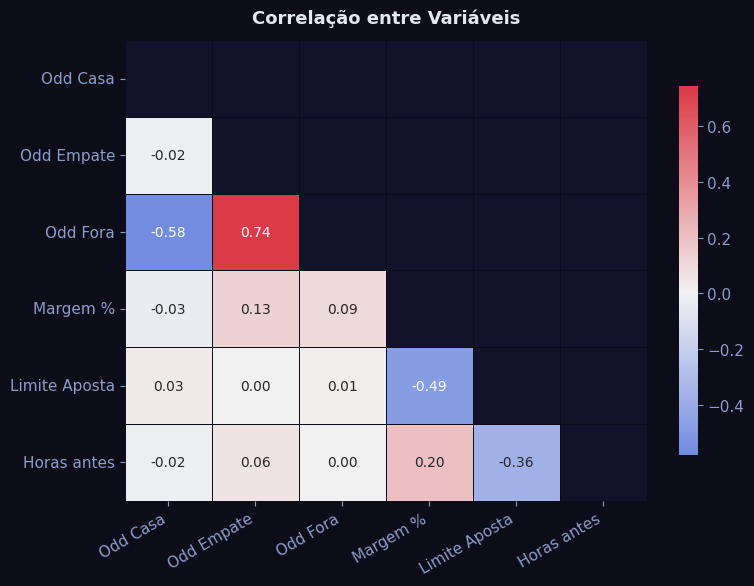

In [24]:
corr_cols = ['home_odds','draw_odds','away_odds','margin_pct','max_money_line','hours_before_start']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(260, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, annot=True, fmt='.2f',
            linewidths=0.5, linecolor='#0D0D1A', ax=ax, annot_kws={'size':10},
            cbar_kws={'shrink':0.8})
ax.set_title('Correlação entre Variáveis', fontsize=13, fontweight='bold', pad=12)
labels_map = {'home_odds':'Odd Casa','draw_odds':'Odd Empate','away_odds':'Odd Fora',
              'margin_pct':'Margem %','max_money_line':'Limite Aposta','hours_before_start':'Horas antes'}
ax.set_xticklabels([labels_map.get(c,c) for c in corr.columns], rotation=30, ha='right')
ax.set_yticklabels([labels_map.get(c,c) for c in corr.index], rotation=0)
plt.tight_layout(); plt.show()

### 3.4 Distribuição de probabilidades implícitas

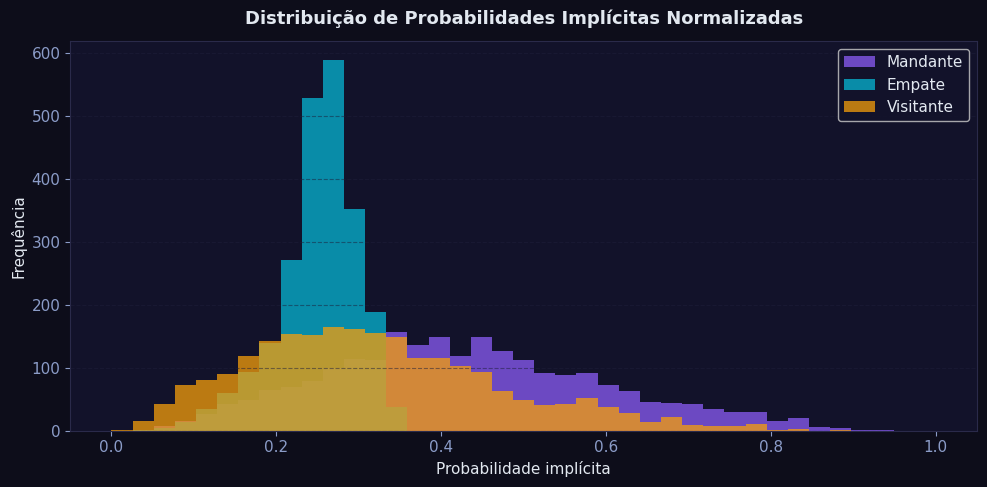

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
bins_prob = np.linspace(0, 1, 40)
ax.hist(df_last['prob_home_norm'], bins=bins_prob, alpha=0.75, color=PURPLE, label='Mandante', edgecolor='none')
ax.hist(df_last['prob_draw_norm'], bins=bins_prob, alpha=0.75, color=CYAN,   label='Empate',   edgecolor='none')
ax.hist(df_last['prob_away_norm'], bins=bins_prob, alpha=0.75, color=AMBER,  label='Visitante', edgecolor='none')
ax.set_title('Distribuição de Probabilidades Implícitas Normalizadas', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Probabilidade implícita'); ax.set_ylabel('Frequência'); ax.legend(); ax.grid(axis='y')
plt.tight_layout(); plt.show()

### 3.5 Volatilidade das odds por liga

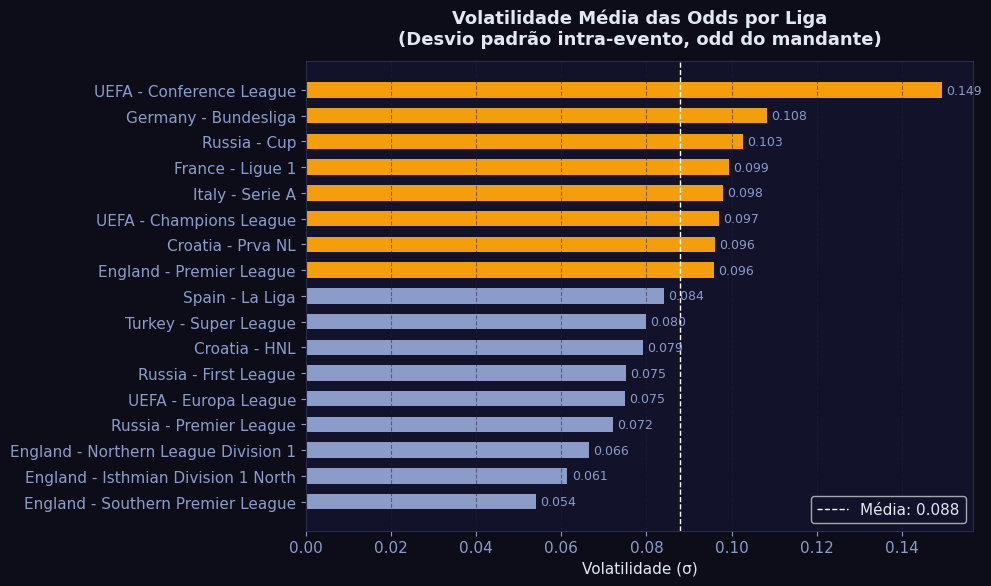

Insight: UEFA - Conference League é a liga com maior variação de odds ao longo do tempo.


In [26]:
volatility = (
    df.groupby(['league_name','event_id'])['home_odds'].std()
    .reset_index()
    .groupby('league_name')['home_odds'].mean()
    .sort_values(ascending=True)
    .rename('volatilidade_media')
)

fig, ax = plt.subplots(figsize=(10, 6))
colors_v = [AMBER if v > volatility.mean() else SLATE for v in volatility.values]
bars = ax.barh(volatility.index, volatility.values, color=colors_v, height=0.6)
ax.axvline(volatility.mean(), color='white', linestyle='--', linewidth=1, label=f'Média: {volatility.mean():.3f}')
ax.set_title('Volatilidade Média das Odds por Liga\n(Desvio padrão intra-evento, odd do mandante)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Volatilidade (σ)'); ax.legend(); ax.grid(axis='x')
for bar in bars:
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9, color=SLATE)
plt.tight_layout(); plt.show()

print(f'Insight: {volatility.idxmax()} é a liga com maior variação de odds ao longo do tempo.')

### 3.6 Favorito × Azarão (scatter com margem da banca)

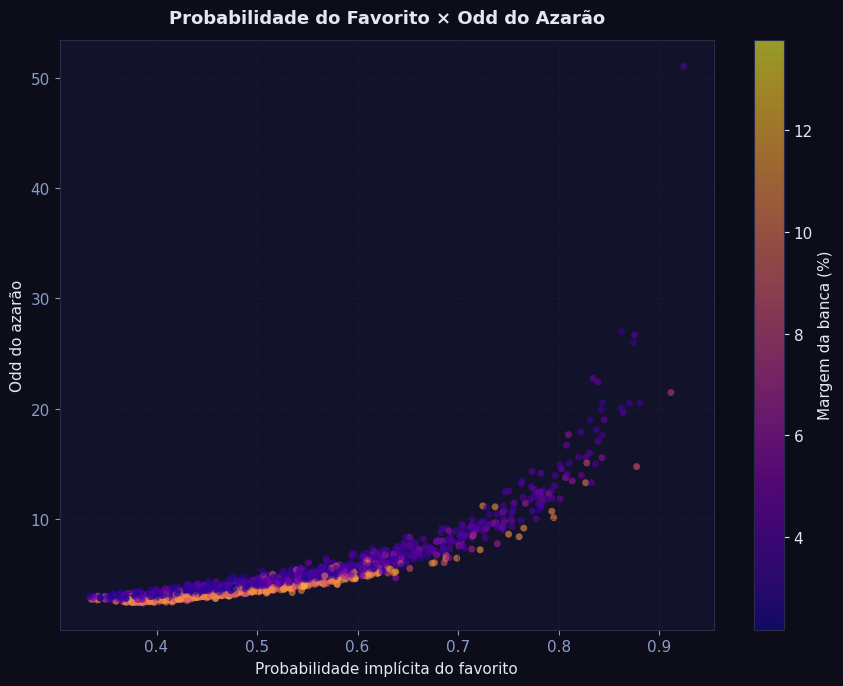

In [27]:
sample = df_last.sample(min(1500, len(df_last)), random_state=42)
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(sample['fav_prob'], sample['underdog_odds'],
                c=sample['margin_pct'], cmap='plasma', alpha=0.6, s=25, edgecolors='none')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Margem da banca (%)', color='#E2E8F0')
cbar.ax.yaxis.set_tick_params(color='#E2E8F0')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#E2E8F0')
ax.set_title('Probabilidade do Favorito × Odd do Azarão', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Probabilidade implícita do favorito'); ax.set_ylabel('Odd do azarão'); ax.grid(True)
plt.tight_layout(); plt.show()

### 3.7 Limite máximo de aposta por liga

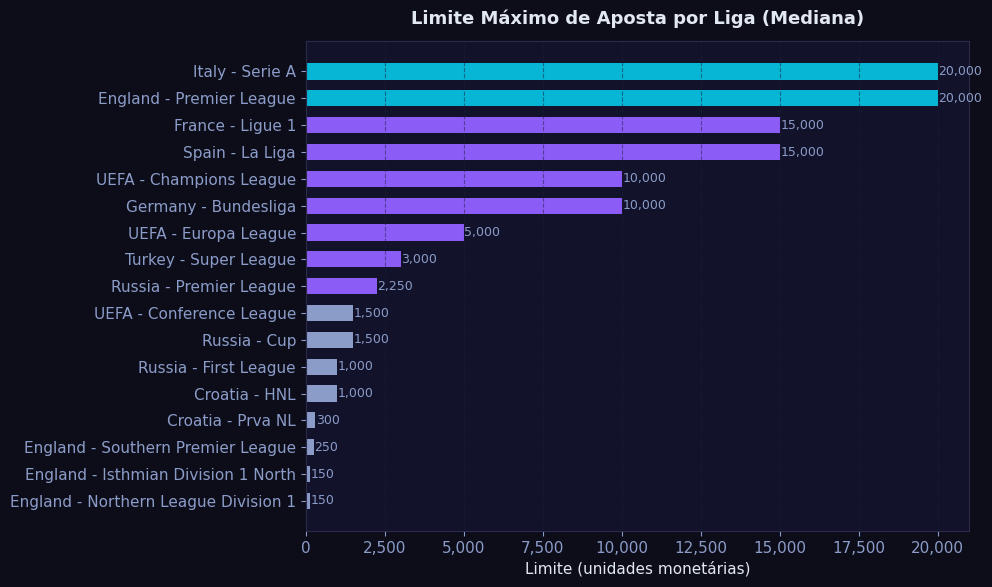

In [28]:
money_line = (
    df_last.dropna(subset=['max_money_line'])
    .groupby('league_name')['max_money_line'].median()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors_ml = [CYAN if v == money_line.max() else (PURPLE if v >= money_line.median() else SLATE)
             for v in money_line.values]
bars = ax.barh(money_line.index, money_line.values, color=colors_ml, height=0.6)
ax.set_title('Limite Máximo de Aposta por Liga (Mediana)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Limite (unidades monetárias)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='x')
for bar in bars:
    ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():,.0f}', va='center', fontsize=9, color=SLATE)
plt.tight_layout(); plt.show()

## 4. Principais Insights

| # | Insight | Detalhe |
|---|---------|----------|
| 1 | **Margem média da banca: 5,05%** | Ligas menores chegam a quase 12%; Serie A é a mais competitiva (4,52%) |
| 2 | **Odds do mandante caem próximo ao jogo** | Nas últimas 24h há uma pressão de mercado em favor do time da casa |
| 3 | **Vantagem do mandante varia por liga** | Ligas do Leste Europeu (Croácia, Rússia) apresentam maior desequilíbrio |
| 4 | **Conference League é a mais volátil** | Maior desvio padrão intra-evento — odds mudam mais durante a semana |
| 5 | **Jogos equilibrados têm maior margem** | Quando favorito e azarão estão próximos em probabilidade, a banca amplia a margem |
| 6 | **UCL e Premier League têm maior liquidez** | Limites de aposta até 40x maiores que ligas menores |